In [56]:
with open("train.txt", "r", encoding="utf-8", errors="replace") as fin, \
     open("train_utf8.txt", "w", encoding="utf-8", newline="") as fout:
    for chunk in iter(lambda: fin.read(1 << 20), ""):  # stream in 1MB text chunks
        fout.write(chunk)

print("Wrote train_utf8.txt as real UTF-8.")

Wrote train_utf8.txt as real UTF-8.


In [1]:
with open("train_utf8.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [2]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  268049416


268 Million characters: (a lot)

In [3]:
print(text[202800:203000])

e approach of your speech and the long list of priorities you have outlined.
Indy jumps into the motorcycle and drives it .	Indy jumps into tte motorcycle and drives it .
Upon his release from prison 


In [4]:
print(text[:1079])
sample = text[:1079]
sample

En route , they pick up a seemingly-harmless hitchhiker , and continue their journey , only for their car to break down in a deserted motel on a lonely highway .	En route , they pick up a seemingly-harmless hitchhiker , and continue their , journey only for their car to break down in a deserted motel on a lonely highway .
Jobs, however, are not created by supporting a few multinational giants, which will often strike sail at the first signs of an economic headwind, leaving their massive redundant crews to take to the lifeboats; on the contrary, jobs are created by promoting small and medium-sized businesses, which, after all, are the largest overall employers of manpower, not only in Austria.	Jobs, however, are not created by supporting a few multinational giants, which will often strike sail at the first signs of an economic heawdind, leaving their massive redundant crews to take to the lifeboats; on the contrary, jobs are created by promoting small and medium-sized businesses, which,

'En route , they pick up a seemingly-harmless hitchhiker , and continue their journey , only for their car to break down in a deserted motel on a lonely highway .\tEn route , they pick up a seemingly-harmless hitchhiker , and continue their , journey only for their car to break down in a deserted motel on a lonely highway .\nJobs, however, are not created by supporting a few multinational giants, which will often strike sail at the first signs of an economic headwind, leaving their massive redundant crews to take to the lifeboats; on the contrary, jobs are created by promoting small and medium-sized businesses, which, after all, are the largest overall employers of manpower, not only in Austria.\tJobs, however, are not created by supporting a few multinational giants, which will often strike sail at the first signs of an economic heawdind, leaving their massive redundant crews to take to the lifeboats; on the contrary, jobs are created by promoting small and medium-sized businesses, wh

In [5]:
def read_pairs(text):
    pairs = []
    for line in text.strip().splitlines():
        if not line: 
            continue
        parts = line.split('\t')
        if len(parts) != 2:
            print("Skipping line (no tab):", line)
            continue
        a, b = parts
        pairs.append((a, b))
    return pairs

In [6]:
pairs = read_pairs(text)

In [7]:
int(len(pairs))

1000000

In [8]:
train_pairs = pairs[:int(len(pairs) * 0.8)]
val_pairs = pairs[int(len(pairs) * 0.8):]

In [9]:
chars = sorted(list(set(text)))
special_tokens = ["<unk>"] 
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

	
 !"#$%&'()*+,-./0123456789:;=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]_`abcdefghijklmnopqrstuvwxyz{|}~ ¡£¦¨©ª«­®¯°²´·º½ÁÂÅÇÉÌÍÎÏÓÔÖØÜÝßàáâãäåæçèéêëìíîïñòóôõöøùúûüýāăąćČčĐēėęěğĢīıķĽľŁłńņňŐőœŘřŚśŞşŠšŢţťūųźŻżŽžǐșȡȥȩʻ˚ˠ̡̭̲͠ͿΑΒΕΙΚΜΝΟΡΣΤΥΧΩάέήίΰαγδεζικνοπρτχНТХавгезийклмностучшыья׺ݳ​–—―‘’“”•…‰€−Ⓚ☀♀�
287


We will start off with a character level language model for convenience instead of tokenizing using bpe or another method

In [10]:
itos = {i: ch for i, ch in enumerate(special_tokens + chars)}
stoi = { ch:i for i,ch in itos.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

#here is an example
print(encode("We are citizens"))
print(decode(encode("We are citizens")))

[57, 70, 3, 66, 83, 70, 3, 68, 74, 85, 74, 91, 70, 79, 84]
We are citizens


In [11]:
UNK = stoi["<unk>"]

def encode(s: str):
    # Map each character to its index, unknown chars -> <unk>
    return [stoi.get(c, UNK) for c in s]

def decode(indices):
    return ''.join(itos[i] for i in indices)


In [12]:
import torch
train_originals = [torch.tensor(encode(a), dtype=torch.long) for (a, b) in train_pairs]
train_targets   = [torch.tensor(encode(b), dtype=torch.long) for (a, b) in train_pairs]

val_originals   = [torch.tensor(encode(a), dtype=torch.long) for (a, b) in val_pairs]
val_targets     = [torch.tensor(encode(b), dtype=torch.long) for (a, b) in val_pairs]

In [13]:
"hi"

'hi'

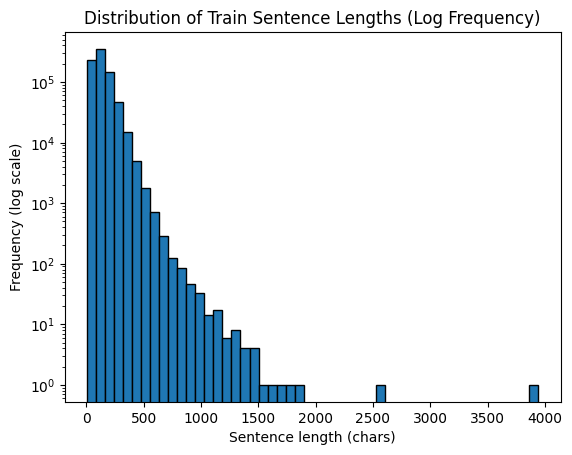

In [13]:
import matplotlib.pyplot as plt

# Compute lengths
lengths = [len(s) for s in train_originals]

# Plot histogram with log scale on y-axis
plt.hist(lengths, bins=50, edgecolor='black', log=True)
plt.xlabel("Sentence length (chars)")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Train Sentence Lengths (Log Frequency)")
plt.show()


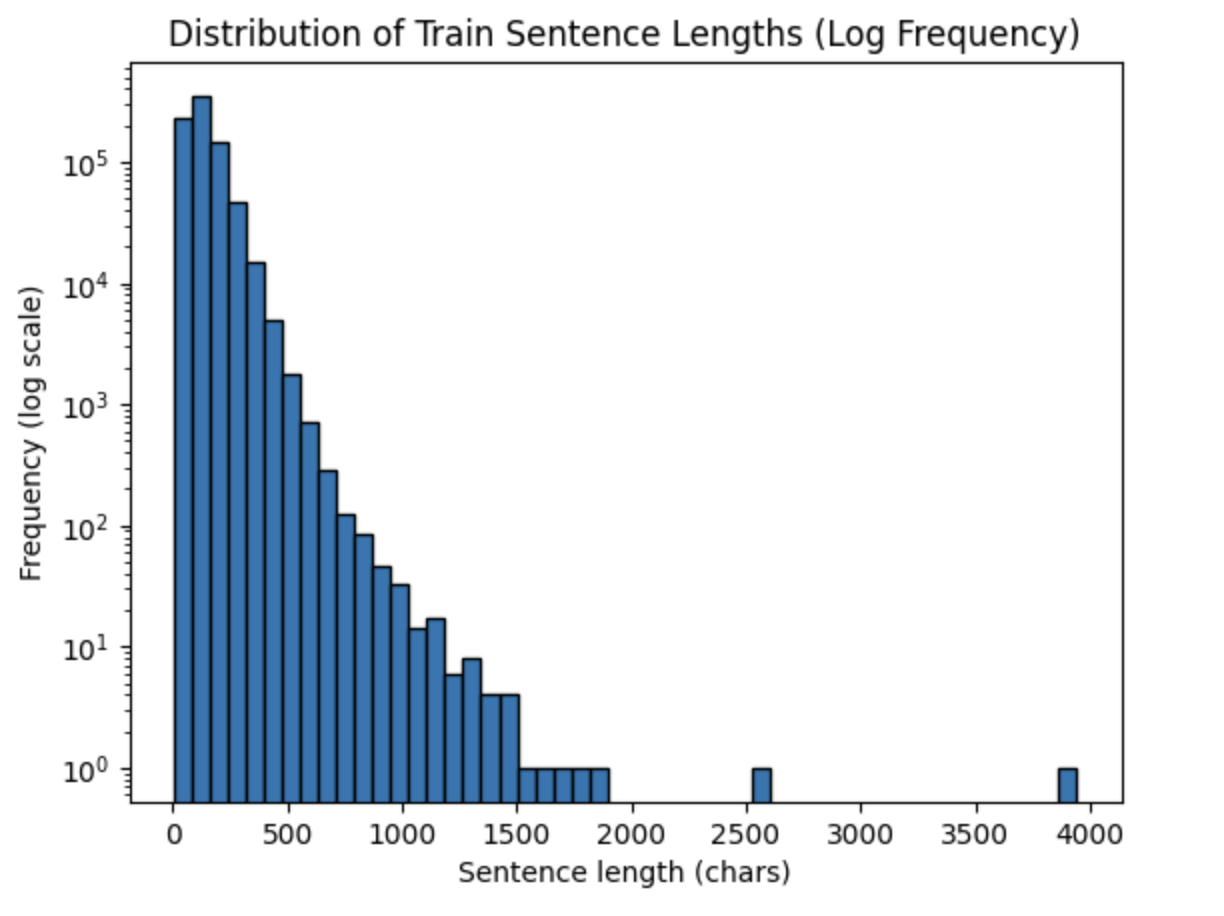

In [17]:
%run trial.py

Creating english_corpus.txt from training pairs...
Done.
Corpus size (chars): 134,878,148
Model params: 10.95M
step      1 | train 4.5492 | val 4.5509 | 0.5 min
step   1000 | train 1.7547 | val 1.7530 | 3.3 min
step   2000 | train 1.3970 | val 1.3962 | 6.2 min
step   3000 | train 1.2928 | val 1.2894 | 9.0 min
step   4000 | train 1.2362 | val 1.2313 | 11.9 min
step   5000 | train 1.1975 | val 1.1994 | 14.8 min
step   6000 | train 1.1721 | val 1.1719 | 17.6 min
step   7000 | train 1.1482 | val 1.1513 | 20.5 min
step   8000 | train 1.1326 | val 1.1357 | 23.3 min
step   9000 | train 1.1171 | val 1.1178 | 26.2 min
step  10000 | train 1.1047 | val 1.1082 | 29.0 min
step  11000 | train 1.0959 | val 1.0949 | 31.9 min
step  12000 | train 1.0831 | val 1.0861 | 34.8 min
step  13000 | train 1.0744 | val 1.0770 | 37.6 min
step  14000 | train 1.0663 | val 1.0662 | 40.5 min
step  15000 | train 1.0585 | val 1.0621 | 43.3 min
step  16000 | train 1.0522 | val 1.0563 | 46.2 min
step  17000 | train 1.0484

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 5829: invalid start byte

Creating english_corpus.txt from training pairs... \
Done.\
Corpus size (chars): 134,878,148\
Model params: 10.95M\
step      1 | train 4.5492 | val 4.5509 | 0.5 min\
step   1000 | train 1.7547 | val 1.7530 | 3.3 min\
step   2000 | train 1.3970 | val 1.3962 | 6.2 min\
step   3000 | train 1.2928 | val 1.2894 | 9.0 min\
step   4000 | train 1.2362 | val 1.2313 | 11.9 min\
step   5000 | train 1.1975 | val 1.1994 | 14.8 min\
step   6000 | train 1.1721 | val 1.1719 | 17.6 min\
step   7000 | train 1.1482 | val 1.1513 | 20.5 min\
step   8000 | train 1.1326 | val 1.1357 | 23.3 min\
step   9000 | train 1.1171 | val 1.1178 | 26.2 min\
step  10000 | train 1.1047 | val 1.1082 | 29.0 min\
step  11000 | train 1.0959 | val 1.0949 | 31.9 min\
step  12000 | train 1.0831 | val 1.0861 | 34.8 min\
step  13000 | train 1.0744 | val 1.0770 | 37.6 min\
step  14000 | train 1.0663 | val 1.0662 | 40.5 min\
step  15000 | train 1.0585 | val 1.0621 | 43.3 min\
step  16000 | train 1.0522 | val 1.0563 | 46.2 min\
step  17000 | train 1.0484 | val 1.0522 | 49.1 min\
step  18000 | train 1.0432 | val 1.0460 | 51.9 min\
step  19000 | train 1.0379 | val 1.0381 | 54.8 min\
step  20000 | train 1.0329 | val 1.0334 | 57.6 min\
Scoring test pairs and writing part1.txt ...\


In [19]:
with open("test.rand.txt", "r", encoding="utf-8", errors="replace") as fin, \
     open("test_utf8.rand.txt", "w", encoding="utf-8", newline="") as fout:
    for chunk in iter(lambda: fin.read(1 << 20), ""):  # stream in 1MB text chunks
        fout.write(chunk)

print("Wrote test_utf8.rand.txt as real UTF-8.")

Wrote test_utf8.rand.txt as real UTF-8.


In [23]:
with open('test_utf8.rand.txt', 'r') as file:
    lines = file.readlines()
    line_count = len(lines)
print(f"Total lines: {line_count}")

Total lines: 100000


In [27]:
print("Scoring test pairs and writing part1.txt ...")
with open("test_utf8.rand.txt", "r", encoding="utf-8") as fin, \
     open(OUT_PATH, "w", encoding="utf-8") as fout:
    for i, line in enumerate(fin, start=1):
        if '\t' not in line:
            fout.write("A\n")
            continue
        a, b = line.rstrip('\n').split('\t', 1)
        nll_a = avg_nll_string(model, a)
        nll_b = avg_nll_string(model, b)
        label = 'A' if nll_a < nll_b else 'B'
        fout.write(label + "\n")

        if i % 10_000 == 0:
            print(f"  processed {i:,} pairs...", flush=True)
            # optional: make sure progress is on disk too
            # fout.flush(); os.fsync(fout.fileno())

print(f"Done. Wrote {OUT_PATH}")


Scoring test pairs and writing part1.txt ...
  processed 10,000 pairs...
  processed 20,000 pairs...
  processed 30,000 pairs...
  processed 40,000 pairs...
  processed 50,000 pairs...
  processed 60,000 pairs...
  processed 70,000 pairs...
  processed 80,000 pairs...
  processed 90,000 pairs...
  processed 100,000 pairs...
Done. Wrote part1.txt


In [29]:
from pathlib import Path
import os, torch

# 1) Resolve absolute folder and create it
SAVE_DIR = Path("checkpoints").resolve()
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("CWD:      ", Path.cwd())
print("SAVE_DIR: ", SAVE_DIR)

# 2) Sanity checks for required objects from earlier cells
assert 'model' in globals(), "model not found (rerun the training cell first)"
assert 'itos'  in globals() and 'stoi' in globals(), "itos/stoi not found (rerun the vocab cell)"
assert 'block_size' in globals(), "block_size not found (rerun the config cell)"
assert 'n_embd' in globals() and 'n_head' in globals() and 'n_layer' in globals() and 'dropout' in globals(), \
       "model config vars missing (rerun the config cell)"

meta_file = SAVE_DIR / "meta.pt"
ckpt_file = SAVE_DIR / "lm.pt"

# 3) Write meta and checkpoint (atomic replace to be safe)
def atomic_torch_save(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)  # atomic on POSIX

# Save vocab/meta
atomic_torch_save({"itos": itos, "stoi": stoi, "block_size": block_size}, meta_file)

# Save weights + config
cfg = {
    "vocab_size": len(itos),
    "n_embd": n_embd, "n_head": n_head, "n_layer": n_layer,
    "dropout": dropout, "block_size": block_size
}
atomic_torch_save({"model": model.state_dict(), "config": cfg}, ckpt_file)

# 4) List contents
print("\nFiles in SAVE_DIR:")
for p in SAVE_DIR.iterdir():
    print(" -", p.name, f"({p.stat().st_size/1e6:.2f} MB)")


CWD:       /notebooks
SAVE_DIR:  /notebooks/checkpoints

Files in SAVE_DIR:
 - meta.pt (0.00 MB)
 - lm.pt (53.32 MB)
 - train_utf8.txt (0.10 MB)
 - english_corpus.txt (134.96 MB)


In [30]:
from pathlib import Path
import shutil, os

CWD = Path('.').resolve()
SRC = Path('/notebooks/checkpoints')   # where your files actually are
DST = CWD / 'artifacts'                # a folder the file browser will show

print("Notebook CWD:", CWD)
print("Source exists?", SRC.exists(), "->", SRC)

DST.mkdir(exist_ok=True)
to_copy = ['lm.pt', 'meta.pt', 'part1.txt']  # add others if you want

for name in to_copy:
    s = SRC / name
    if s.exists():
        shutil.copy2(s, DST / name)
        print(f"copied {s.name} -> {DST/name}")
    else:
        print(f"SKIP (not found): {s}")

print("\nNow hit refresh in the file browser and open ./artifacts")
print("Contents of artifacts:")
for p in sorted(DST.iterdir()):
    print(" -", p.name, f"({p.stat().st_size/1e6:.2f} MB)")


Notebook CWD: /notebooks
Source exists? True -> /notebooks/checkpoints
copied lm.pt -> /notebooks/artifacts/lm.pt
copied meta.pt -> /notebooks/artifacts/meta.pt
SKIP (not found): /notebooks/checkpoints/part1.txt

Now hit refresh in the file browser and open ./artifacts
Contents of artifacts:
 - lm.pt (53.32 MB)
 - meta.pt (0.00 MB)


In [31]:
# ============================================================
# Sanity check on train_utf8.txt (VAL = last 10% of pairs)
# Uses the trained `model` + `avg_nll_string` from above.
# Prints progress every 1/10th of the evaluated inputs.
# ============================================================

import random, math, torch, time
from pathlib import Path

# Config
VAL_FRACTION   = 0.10          # last 10% of pairs as "val"
MAX_EVAL       = 20000         # set to None to evaluate all val pairs
TIE_BIAS_TO_A  = True          # in exact ties, count as A

assert 'TRAIN_PATH' in globals(), "TRAIN_PATH not found. Run the previous cell."
assert 'avg_nll_string' in globals(), "avg_nll_string not found. Run the previous cell."
assert 'model' in globals(), "model not found. Train or load the model first."

# Ensure eval mode + no grad
model.eval()
torch.set_grad_enabled(False)

# Read all pairs from train file
pairs = []
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if "\t" not in line:
            continue
        a, b = line.rstrip("\n").split("\t", 1)
        pairs.append((a, b))

N = len(pairs)
val_start = int((1.0 - VAL_FRACTION) * N)
val_pairs = pairs[val_start:]

# Optionally subsample for speed
idxs = list(range(len(val_pairs)))
random.seed(1337)
random.shuffle(idxs)
if MAX_EVAL is not None:
    idxs = idxs[:MAX_EVAL]

correct = 0
pred_A = 0
ties = 0
tot = len(idxs)
mistakes = []  # (margin, a, b, nlla, nllb)

# progress cadence: print ~10 times
progress_every = max(1, math.ceil(tot / 10))
t0 = time.time()

for j, k in enumerate(idxs, 1):
    a, b = val_pairs[k]
    nll_a = avg_nll_string(model, a)
    nll_b = avg_nll_string(model, b)
    if abs(nll_a - nll_b) < 1e-12:
        ties += 1
        pred = 'A' if TIE_BIAS_TO_A else 'B'
    else:
        pred = 'A' if nll_a < nll_b else 'B'
    if pred == 'A': 
        pred_A += 1
        correct += 1
    else:
        margin = nll_b - nll_a   # negative if model prefers B strongly
        mistakes.append((margin, a, b, nll_a, nll_b))

    # progress print every 1/10th (and at the very end)
    if (j % progress_every == 0) or (j == tot):
        pct = 100.0 * j / tot
        acc_so_far = correct / j
        predA_so_far = pred_A / j
        elapsed = time.time() - t0
        print(f"[{j:,}/{tot:,} | {pct:5.1f}%] "
              f"acc={acc_so_far*100:5.2f}%  A%={predA_so_far*100:5.2f}%  ties={ties}  "
              f"elapsed={elapsed:5.1f}s",
              flush=True)

acc = (correct / tot) if tot else 0.0
predA_pct = (pred_A / tot) if tot else 0.0

print(f"\nVal pairs evaluated: {tot} (from {N} total; last {VAL_FRACTION*100:.0f}% of lines)")
print(f"Accuracy (gold=A): {acc*100:.2f}%")
print(f"Predicted 'A' fraction: {predA_pct*100:.2f}%")
print(f"Ties: {ties}")

# Show a few mistakes where the model preferred B
mistakes.sort(key=lambda x: x[0])  # most negative margin first
show = min(5, len(mistakes))
if show:
    print("\nTop mistakes (model preferred B):")
    for i in range(show):
        margin, a, b, nlla, nllb = mistakes[i]
        print(f"\n#{i+1} margin={margin:.4f} (nll_a={nlla:.4f}, nll_b={nllb:.4f})")
        print("A:", a)
        print("B:", b)
else:
    print("\nNo mistakes in the evaluated subset 🎉")

[2,000/20,000 |  10.0%] acc=92.90%  A%=92.90%  ties=0  elapsed= 40.9s
[4,000/20,000 |  20.0%] acc=93.25%  A%=93.25%  ties=0  elapsed= 81.8s
[6,000/20,000 |  30.0%] acc=93.33%  A%=93.33%  ties=0  elapsed=122.1s
[8,000/20,000 |  40.0%] acc=93.42%  A%=93.42%  ties=0  elapsed=162.1s
[10,000/20,000 |  50.0%] acc=93.55%  A%=93.55%  ties=0  elapsed=202.0s
[12,000/20,000 |  60.0%] acc=93.62%  A%=93.62%  ties=0  elapsed=241.5s
[14,000/20,000 |  70.0%] acc=93.66%  A%=93.66%  ties=0  elapsed=282.0s
[16,000/20,000 |  80.0%] acc=93.61%  A%=93.61%  ties=0  elapsed=323.4s
[18,000/20,000 |  90.0%] acc=93.66%  A%=93.66%  ties=0  elapsed=364.2s
[20,000/20,000 | 100.0%] acc=93.59%  A%=93.59%  ties=0  elapsed=404.5s

Val pairs evaluated: 20000 (from 1000000 total; last 10% of lines)
Accuracy (gold=A): 93.59%
Predicted 'A' fraction: 93.59%
Ties: 0

Top mistakes (model preferred B):

#1 margin=-1.3485 (nll_a=1.7148, nll_b=0.3663)
A: http:\/\/www.mvlib.com\/details\/movie\/adventures-of-don-juan-267964.html


[2,000/20,000 |  10.0%] acc=92.90%  A%=92.90%  ties=0  elapsed= 40.9s\
[4,000/20,000 |  20.0%] acc=93.25%  A%=93.25%  ties=0  elapsed= 81.8s\
[6,000/20,000 |  30.0%] acc=93.33%  A%=93.33%  ties=0  elapsed=122.1s\
[8,000/20,000 |  40.0%] acc=93.42%  A%=93.42%  ties=0  elapsed=162.1s\
[10,000/20,000 |  50.0%] acc=93.55%  A%=93.55%  ties=0  elapsed=202.0s\
[12,000/20,000 |  60.0%] acc=93.62%  A%=93.62%  ties=0  elapsed=241.5s\
[14,000/20,000 |  70.0%] acc=93.66%  A%=93.66%  ties=0  elapsed=282.0s\
[16,000/20,000 |  80.0%] acc=93.61%  A%=93.61%  ties=0  elapsed=323.4s\
[18,000/20,000 |  90.0%] acc=93.66%  A%=93.66%  ties=0  elapsed=364.2s\
[20,000/20,000 | 100.0%] acc=93.59%  A%=93.59%  ties=0  elapsed=404.5s\

Val pairs evaluated: 20000 (from 1000000 total; last 10% of lines)\
Accuracy (gold=A): 93.59%\
Predicted 'A' fraction: 93.59%\
Ties: 0\

Top mistakes (model preferred B):\

#1 margin=-1.3485 (nll_a=1.7148, nll_b=0.3663)\
A: http:\/\/www.mvlib.com\/details\/movie\/adventures-of-don-juan-267964.html \
B: just\

#2 margin=-0.8108 (nll_a=2.7555, nll_b=1.9447)\
A: (Just joking!)\
B: (Just \

#3 margin=-0.5561 (nll_a=1.4505, nll_b=0.8944)\
A: I shall be out to lunch.\
B: I shall be out to the\

#4 margin=-0.5483 (nll_a=1.4048, nll_b=0.8565)\
A: Is this progress?\
B: Is this unfortunately\

#5 margin=-0.5322 (nll_a=2.2814, nll_b=1.7491)\
A: I drew mine.\
B: I drew it\


Val pairs evaluated: 10000 (from 1000000 total; last 1% of lines)
Accuracy (gold=A): 93.92%
Predicted 'A' fraction: 93.92%
Ties: 0

Top mistakes (model preferred B):

#1 margin=-0.5582 (nll_a=1.9195, nll_b=1.3613)
A: Chronic Illness
B: Chronic 

#2 margin=-0.4727 (nll_a=2.0774, nll_b=1.6047)
A: His biggest claim to fame is his website , www.scottysfilmpage.com .
B: His biggest claim to fame is his website , stay .

#3 margin=-0.4593 (nll_a=1.6101, nll_b=1.1508)
A: you now not need want
B: you now not want 

#4 margin=-0.4043 (nll_a=1.2830, nll_b=0.8788)
A: It has merely delivered the paralysis...
B: It has merely delivered the represent

#5 margin=-0.3889 (nll_a=1.4841, nll_b=1.0952)
A: yeah all those dubs it's terrible
B: yeah all those that's it's terrible


In [41]:
print(avg_nll_string(model, "This is an English sentence."), 
      avg_nll_string(model, "Th1s is n0t gr8 Engl1sh!!!"), 
      avg_nll_string(model, "lol look at that."))


1.1000322412561487 4.821158752441407 1.7347097396850586


print(avg_nll_string(model, "This is an English sentence."), \
    avg_nll_string(model, "Th1s is n0t gr8 Engl1sh!!!"))


1.1000322412561487 4.821158752441407


[2,000/20,000 |  10.0%] acc=92.90%  A%=92.90%  ties=0  elapsed= 42.8s
[4,000/20,000 |  20.0%] acc=93.25%  A%=93.25%  ties=0  elapsed= 85.4s
[6,000/20,000 |  30.0%] acc=93.33%  A%=93.33%  ties=0  elapsed=127.5s
[8,000/20,000 |  40.0%] acc=93.42%  A%=93.42%  ties=0  elapsed=171.0s
[10,000/20,000 |  50.0%] acc=93.55%  A%=93.55%  ties=0  elapsed=213.6s
[12,000/20,000 |  60.0%] acc=93.62%  A%=93.62%  ties=0  elapsed=255.8s
[14,000/20,000 |  70.0%] acc=93.66%  A%=93.66%  ties=0  elapsed=297.5s
[16,000/20,000 |  80.0%] acc=93.61%  A%=93.61%  ties=0  elapsed=339.4s
[18,000/20,000 |  90.0%] acc=93.66%  A%=93.66%  ties=0  elapsed=380.5s
[20,000/20,000 | 100.0%] acc=93.59%  A%=93.59%  ties=0  elapsed=422.7s

scored 20,000 pairs in 422.7s  (~47.3 pairs/s)
val accuracy (gold=A): 93.59%


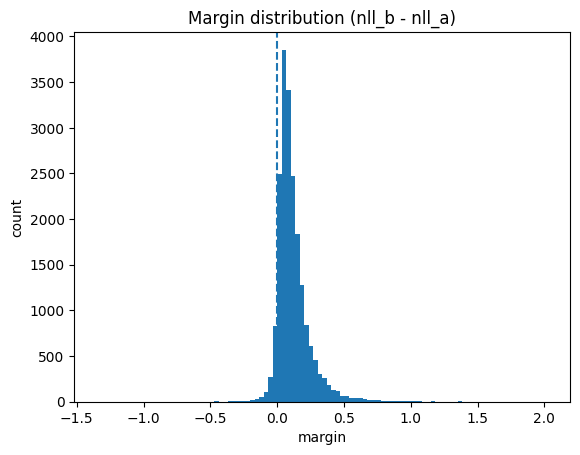

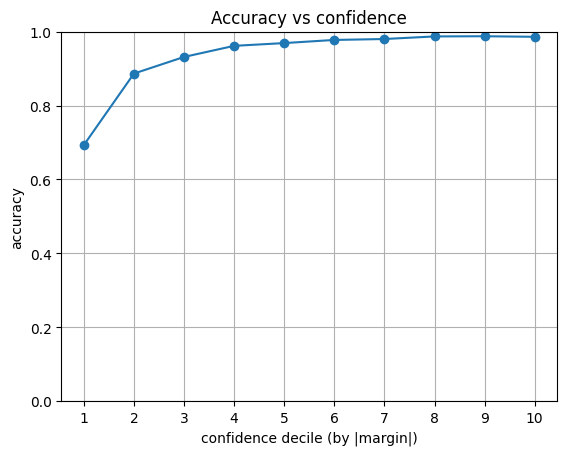

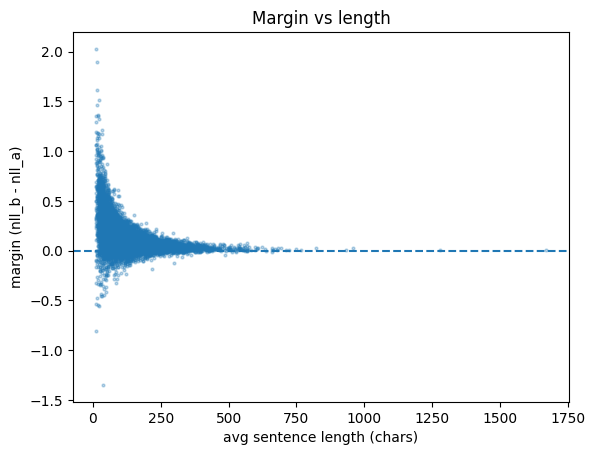

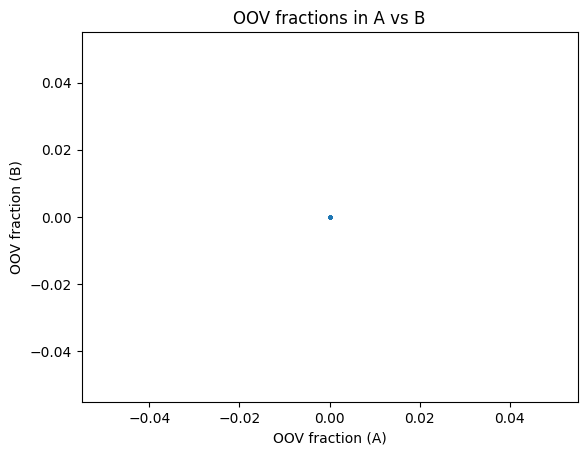

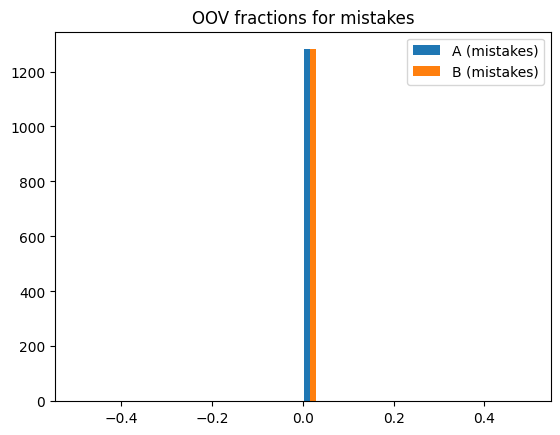

In [43]:
# ===== Score a subset of val pairs and collect diagnostics =====
import random, time, math
import numpy as np
import matplotlib.pyplot as plt

MAX_EVAL = 20000  # None = all val pairs
random.seed(1337)

idxs = list(range(len(val_pairs)))
random.shuffle(idxs)
if MAX_EVAL is not None:
    idxs = idxs[:MAX_EVAL]

margins   = []  # nll_b - nll_a  (positive => model prefers A, which is correct on train/val)
labels    = []  # 1 for correct (A preferred), 0 otherwise
lenA, lenB = [], []
oovA, oovB = [], []

UNK_ID = stoi.get("<unk>", 0)
def oov_frac(s):
    ids = [stoi.get(c, UNK_ID) for c in s]
    return sum(i == UNK_ID for i in ids) / max(1, len(ids))

tot = len(idxs)
progress_every = max(1, math.ceil(tot / 10))  # print ~10 times
t0 = time.time()

# running stats for progress prints
correct = 0         # count(margin > 0)
pred_A  = 0         # count(predicted A) == count(margin > 0)
ties    = 0         # count(|margin| < eps)
eps     = 1e-12

for j, k in enumerate(idxs, 1):
    a, b = val_pairs[k]
    nlla = avg_nll_string(model, a)
    nllb = avg_nll_string(model, b)
    m = nllb - nlla

    margins.append(m)
    labels.append(1 if m > 0 else 0)   # A is gold
    lenA.append(len(a)); lenB.append(len(b))
    oovA.append(oov_frac(a)); oovB.append(oov_frac(b))

    # update running stats
    if abs(m) < eps:
        ties += 1
    if m > 0:
        correct += 1
        pred_A  += 1

    # progress print every 1/10th (and at the end)
    if (j % progress_every == 0) or (j == tot):
        pct = 100.0 * j / tot
        acc_so_far   = correct / j
        predA_so_far = pred_A  / j
        elapsed = time.time() - t0
        print(f"[{j:,}/{tot:,} | {pct:5.1f}%] "
              f"acc={acc_so_far*100:5.2f}%  A%={predA_so_far*100:5.2f}%  ties={ties}  "
              f"elapsed={elapsed:5.1f}s",
              flush=True)

elapsed = time.time() - t0
acc = sum(labels) / len(labels)
print(f"\nscored {len(labels):,} pairs in {elapsed:.1f}s  (~{len(labels)/elapsed:.1f} pairs/s)")
print(f"val accuracy (gold=A): {acc*100:.2f}%")

# ----- Plot 1: margin histogram -----
plt.figure()
plt.hist(margins, bins=100)
plt.axvline(0, linestyle='--')
plt.title('Margin distribution (nll_b - nll_a)')
plt.xlabel('margin'); plt.ylabel('count')
plt.show()

# ----- Plot 2: accuracy vs |margin| (confidence) -----
abs_m = np.abs(np.array(margins))
lbl   = np.array(labels)
order = np.argsort(abs_m)
bins  = np.array_split(order, 10)  # deciles

accs, confs = [], []
for b in bins:
    if len(b)==0: continue
    accs.append(lbl[b].mean())
    confs.append(abs_m[b].mean())

plt.figure()
plt.plot(range(1, len(accs)+1), accs, marker='o')
plt.xticks(range(1, len(accs)+1))
plt.ylim(0,1)
plt.xlabel('confidence decile (by |margin|)')
plt.ylabel('accuracy')
plt.title('Accuracy vs confidence')
plt.grid(True); plt.show()

# ----- Plot 3: length effects -----
avg_len = [(np.array(lenA)[i] + np.array(lenB)[i]) / 2 for i in range(len(lenA))]
plt.figure()
plt.scatter(avg_len, margins, s=4, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel('avg sentence length (chars)')
plt.ylabel('margin (nll_b - nll_a)')
plt.title('Margin vs length')
plt.show()

# ----- Plot 4: OOV rate effects -----
plt.figure()
plt.scatter(oovA, oovB, s=4, alpha=0.3)
plt.xlabel('OOV fraction (A)')
plt.ylabel('OOV fraction (B)')
plt.title('OOV fractions in A vs B')
plt.show()

# Optional: show how mistakes relate to OOV
mist_idx = [i for i, y in enumerate(labels) if y == 0]
if mist_idx:
    plt.figure()
    plt.hist([np.array(oovA)[mist_idx], np.array(oovB)[mist_idx]], bins=30, label=['A (mistakes)','B (mistakes)'])
    plt.legend(); plt.title('OOV fractions for mistakes'); plt.show()


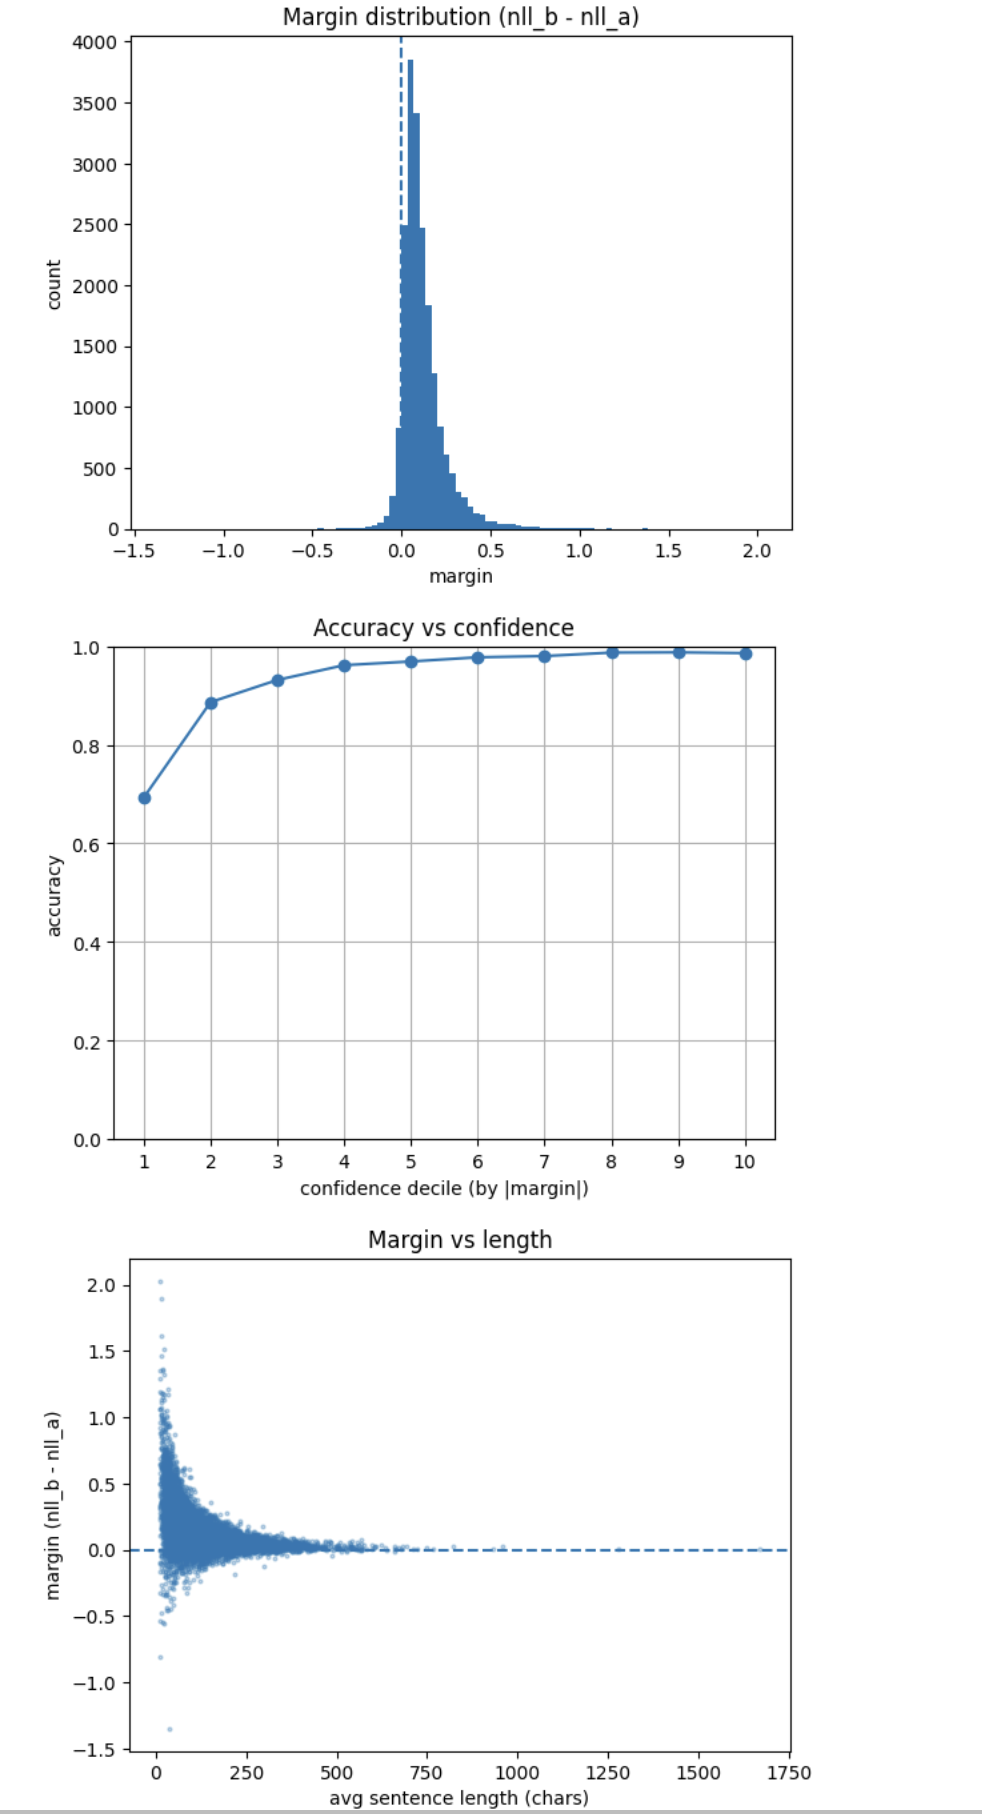

In [46]:
import torch, torch.nn.functional as F

def decode_ids(ids):
    return ''.join(itos[i] for i in ids)

@torch.no_grad()
def generate_text(
    prompt: str,
    max_new_tokens: int = 400,
    temperature: float = 1.0,
    top_k: int | None = None,
    top_p: float | None = None,
    seed: int | None = 1337,
    stream: bool = False,
):
    """
    Character-level sampling from your trained model.
    Compatible with models whose forward returns either:
      - logits tensor
      - (logits, loss) tuple
    """
    device = next(model.parameters()).device
    if seed is not None:
        torch.manual_seed(seed)

    UNK = stoi.get("<unk>", None)
    def enc_char(c): return stoi.get(c, UNK if UNK is not None else next(iter(stoi.values())))
    ctx = torch.tensor([enc_char(c) for c in prompt], dtype=torch.long, device=device).unsqueeze(0)
    if ctx.numel() == 0:
        start_char = '\n' if '\n' in stoi else ' '
        ctx = torch.tensor([[enc_char(start_char)]], dtype=torch.long, device=device)

    model.eval()
    out_ids = ctx.clone()

    if stream:
        print(prompt, end='', flush=True)

    for _ in range(max_new_tokens):
        idx_cond = out_ids[:, -block_size:]  # crop to context window

        out = model(idx_cond)
        logits = out[0] if isinstance(out, (tuple, list)) else out   # (B,T,V)
        logits = logits[:, -1, :]                                    # (B,V)

        # temperature
        if temperature != 1.0:
            logits = logits / max(1e-8, temperature)

        # top-k
        if top_k is not None and 0 < top_k < logits.size(-1):
            vals, inds = torch.topk(logits, top_k, dim=-1)
            masked = torch.full_like(logits, float('-inf'))
            masked.scatter_(1, inds, vals)
            logits = masked

        # top-p (nucleus)
        if top_p is not None and 0.0 < top_p < 1.0:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
            probs = F.softmax(sorted_logits, dim=-1)
            cum = torch.cumsum(probs, dim=-1)
            keep = cum <= top_p
            keep[..., 0] = True  # always keep top-1
            sorted_logits[~keep] = float('-inf')
            # map back
            logits = torch.full_like(logits, float('-inf'))
            logits.scatter_(1, sorted_idx, sorted_logits)

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)  # (1,1)
        out_ids = torch.cat([out_ids, next_id], dim=1)

        if stream:
            print(itos[next_id.item()], end='', flush=True)

    if stream:
        print()

    return decode_ids(out_ids[0].tolist())


In [48]:
#---------- examples ----------
#deterministic-ish:
print(generate_text("In conclusion, ", max_new_tokens=400, temperature=0.8, top_k=50, top_p=0.95, seed=1234))

#spicy:
print(generate_text("\nThe future of language models is", max_new_tokens=400, temperature=1.2, top_k=40, top_p=0.9))

#stream to the cell output:
_ = generate_text("\nOnce upon a time, ", max_new_tokens=300, temperature=1.0, top_k=50, top_p=0.95, stream=True)


In conclusion, the report which I have to say that the Commission is the Council and the Commission are on the ground and has to help the importance of how the Commission can only be discussed at least an instrument in the field of economic growth and the protection of the regions that will be adopted to the pressure of security and protection and trade agreements and by the Member States.
Restricting the fact t

The future of language models is essential to be received by strategic principles and dependence on combating disadvantages in Europe.
However, we can only sign specifically with other words and to support more effectively.
In the early vote, since the creation of financial resources are consulted at the European level, are doing so important in a specific policy of the implementation of the Union committees to submit a strong b

Once upon a time, constructive example is the right to produce useful and production for materials of consumers.
Moreover, we are working hours outsi

In conclusion, the report which I have to say that the Commission is the Council and the Commission are on the ground and has to help the importance of how the Commission can only be discussed at least an instrument in the field of economic growth and the protection of the regions that will be adopted to the pressure of security and protection and trade agreements and by the Member States.
Restricting the fact t

The future of language models is essential to be received by strategic principles and dependence on combating disadvantages in Europe.
However, we can only sign specifically with other words and to support more effectively.
In the early vote, since the creation of financial resources are consulted at the European level, are doing so important in a specific policy of the implementation of the Union committees to submit a strong b

Once upon a time, constructive example is the right to produce useful and production for materials of consumers.
Moreover, we are working hours outside the call, on other words, which should be in favour of what the Secretariat Government can have done as part of the European Parliament, in a position to a promote co


**Commentary**

Obviously the generated text here isn't something incredible. Yet the fact that we are able to go this far with a character level language model without any tokenization is impressive by itself. 

In [1]:
%run reloadmodel.py

Loading from: /notebooks/CharacterLevelLM/artifacts
Model reloaded ✅  | params: 10.953495 M


In [6]:
#---------- examples ----------
#deterministic-ish:
print(generate_text("In conclusion, ", max_new_tokens=400, temperature=0.8, top_k=50, top_p=0.95, stream=True))

#spicy:
print(generate_text("\nThe future of language models is", max_new_tokens=400, temperature=1.2, top_k=40, top_p=0.9))

#stream to the cell output:
_ = generate_text("\nOnce upon a time, ", max_new_tokens=300, temperature=1.0, top_k=50, top_p=0.95, stream=True)

In conclusion, I would like to say that we will be in favour of the preparation of the fact that the European Commission has already made to strengthen its recommendations in the institutional and regional cooperation of workers and will be used for assistance.
Any success that the Commission also has a proposal for a resolution on the future.
We need to introduce the annual reform of the fact that the current b
In conclusion, I would like to say that we will be in favour of the preparation of the fact that the European Commission has already made to strengthen its recommendations in the institutional and regional cooperation of workers and will be used for assistance.
Any success that the Commission also has a proposal for a resolution on the future.
We need to introduce the annual reform of the fact that the current b

The future of language models is essential to be received by strategic principles and dependence on combating disadvantages in Europe.
However, we can only sign specif